In [1]:
#def get_obs_id_from_h5dl1_file(h5dl1InName):
#"/dl1/event/telescope/parameters/tel_001"
#col name is obs_id
#print(h5file)
#print(table)
#print(table[:]['energy'])
#print("for node in h5file")
#for node in h5file:
#print(node)
#h5file = open_file(h5dl1InName, "a")
#table = h5file.root.dl1.event.telescope.parameters.tel_001
#obs_id=int(np.mean(table[:]['obs_id']))
#obs_id_std=np.std(table[:]['obs_id'])
#print(obs_id)
#print(np.std(table[:]['obs_id']))
#h5file.close()
#if (obs_id_std == 0.0) :
#return obs_id
#return -999
#
import pandas as pd
import numpy as np
import glob
import gc
import matplotlib.pyplot as plt
from matplotlib import colors
from astropy.coordinates import SkyCoord, AltAz, angular_separation
import astropy.units as u
from scipy.stats import binned_statistic
from scipy.signal import lombscargle
import h5py
from astropy.io import fits
from astropy.table import Table
from tables import open_file

from astropy.table import join, vstack
from ctapipe.io import read_table 

from ctapipe.instrument import SubarrayDescription
from matplotlib.colors import LogNorm


import math

In [2]:
subarr=SubarrayDescription.read(
        "dataset://gamma_prod5.simtel.zst",
        focal_length_choice="EQUIVALENT")

In [3]:
#SST-1M DigiCam (corsika_theta_20.0_az_180.0_run10.simtel.gz)
#geom = subarr.tel[4].camera.geometry
#optics = subarr.tel[4].optics

#Mace (corsika_theta_20.0_az_180.0_run10.simtel.gz)
#geom = subarr.tel[1].camera.geometry
#optics = subarr.tel[1].optics


#LST LSTCam
#geom = subarr.tel[1].camera.geometry
#optics = subarr.tel[1].optics
#MST FlashCam
#geom = subarr.tel[5].camera.geometry
#optics = subarr.tel[5].optics
#MST NectarCam
geom = subarr.tel[100].camera.geometry
optics = subarr.tel[100].optics
#SST CHEC
#geom = subarr.tel[60].camera.geometry
#optics = subarr.tel[60].optics

#geom = subarr.tel[50].camera.geometry

#geom = subarr.tel[8].camera.geometry
#def prod5_mst_flashcam(subarray_prod5_paranal):
#    return subarray_prod5_paranal.tel[5]
#def prod5_mst_nectarcam(subarray_prod5_paranal):
#    return subarray_prod5_paranal.tel[100]
#def prod5_lst(subarray_prod5_paranal):
#    return subarray_prod5_paranal.tel[1]
#def prod5_sst(subarray_prod5_paranal):
#    return subarray_prod5_paranal.tel[60]

In [4]:
from ctapipe.visualization import CameraDisplay

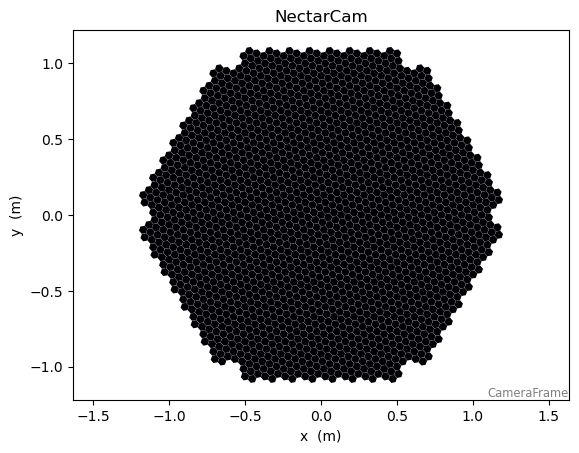

In [5]:
disp = CameraDisplay(geom)

In [6]:
#h5file=open_file("data/run_000/dl1_muon_ctapipe_run000_dev.h5", "a")
#h5file=open_file("data/test/muon-_0deg_0deg_run000002___cta-prod6-2147m-Paranal-mst-nc-dark-ref-degraded-0.8.h5", "a")
#h5file=open_file("/home/burmist/Downloads/muon-_0deg_0deg_run000001___cta-prod6-2147m-Paranal-mst-nc-dark-ref-degraded-0.8.simtel.zst", "a")
h5file=open_file("./data/data_muon_verticle_no_magnetic_field/muon-_0deg_0deg_run000001___cta-prod6-2147m-Paranal-mst-nc-dark-ref-degraded-0.8.h5", "a")

In [7]:
h5file.root.dl1.event.telescope.images.tel_001[:]

array([(1,     100, 1, [-11,  -5,  -6, ..., -12,   7,  -2], [1646, 1825, 1705, ..., 1714, 1598, 1954], [False, False, False, ..., False, False, False],  True),
       (1,     200, 1, [-14,  15,   9, ...,  -1,   0,  -8], [1646, 1536, 1570, ..., 1873, 1725, 1400], [False, False, False, ..., False, False, False],  True),
       (1,     300, 1, [ -9,  10, -12, ..., -11,  18,  -6], [1746, 1667, 2105, ..., 1814, 1683, 1569], [False, False, False, ..., False, False, False],  True),
       ...,
       (1,  999800, 1, [  1,  -5,   6, ...,   7,  -9,  18], [1523, 1584, 1795, ..., 1785, 1597, 1808], [False, False, False, ..., False, False, False],  True),
       (1,  999900, 1, [  3, -14,  -7, ...,  -7,  -4,   0], [1667, 1657, 1705, ..., 1714, 2038, 1591], [False, False, False, ..., False, False, False],  True),
       (1, 1000000, 1, [  1, -12, -12, ...,   9,  13,  22], [1829, 1657, 1705, ..., 1678, 1584, 1650], [False, False, False, ..., False, False, False],  True)],
      shape=(9965,), dtype=

In [8]:
h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][0]

array([0, 0, 0, ..., 0, 0, 0], shape=(1855,), dtype=int32)

In [9]:
h5file.root.simulation.event.subarray.shower[:]['true_core_y'][0]

np.float64(1.1162625551223755)

600


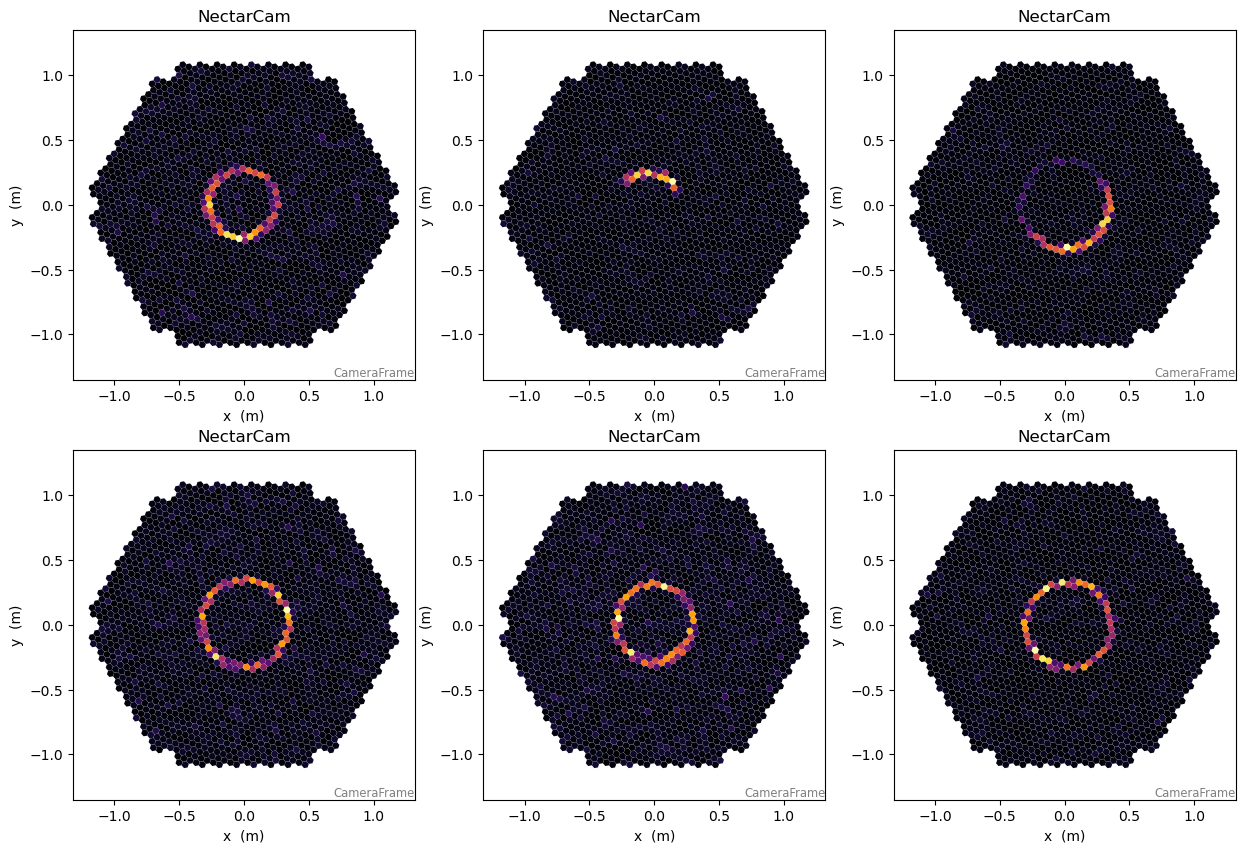

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][0],
    ax=ax[0][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][1],
    ax=ax[0][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][2],
    ax=ax[0][2])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][3],
    ax=ax[1][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][4],
    ax=ax[1][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][5],
    ax=ax[1][2])
print(h5file.root.dl1.event.telescope.images.tel_001[:]['event_id'][5])

In [11]:
rrrr=np.sqrt(h5file.root.simulation.event.subarray.shower[:]['true_core_x'] ** 2 + h5file.root.simulation.event.subarray.shower[:]['true_core_y'] ** 2)

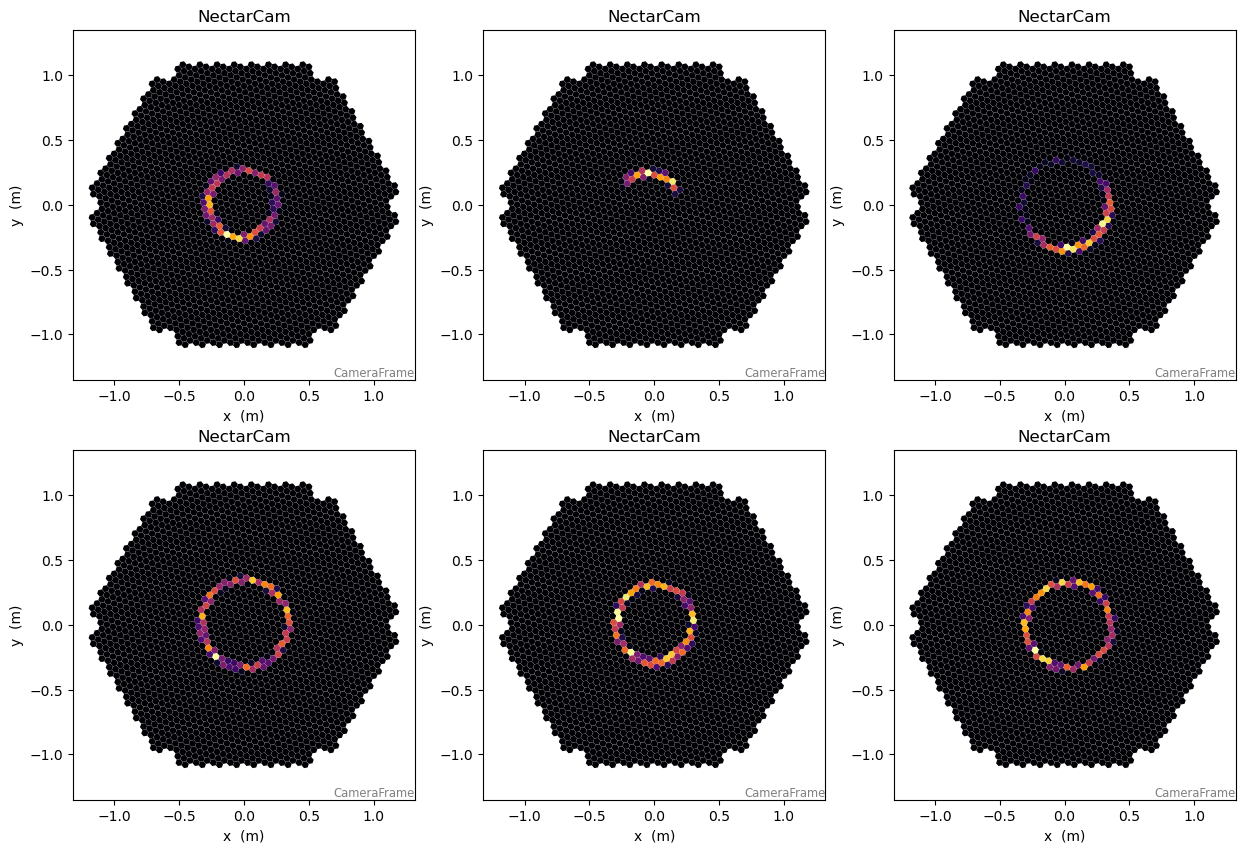

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][0],
    ax=ax[0][0])
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][1],
    ax=ax[0][1])
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][2],
    ax=ax[0][2])
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][3],
    ax=ax[1][0])
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][4],
    ax=ax[1][1])
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][5],
    ax=ax[1][2])
#print(h5file.root.dl1.event.telescope.images.tel_001[:]['event_id'][5])

In [13]:
for i in np.arange(6):
    print(i+1," ",rrrr[i])

1   5.8047231202757645
2   6.75092007468436
3   5.027354024326035
4   2.794655814092708
5   3.197689984479763
6   1.32767032863265


In [14]:
optics

OpticsDescription(name=MST, size_type=MST, reflector_shape=HYBRID, equivalent_focal_length=16.00 m, effective_focal_length=16.45 m, n_mirrors=1, mirror_area=106.24 m2)

In [15]:
np.sqrt(optics.mirror_area/np.pi)

<Quantity 5.81529654 m>

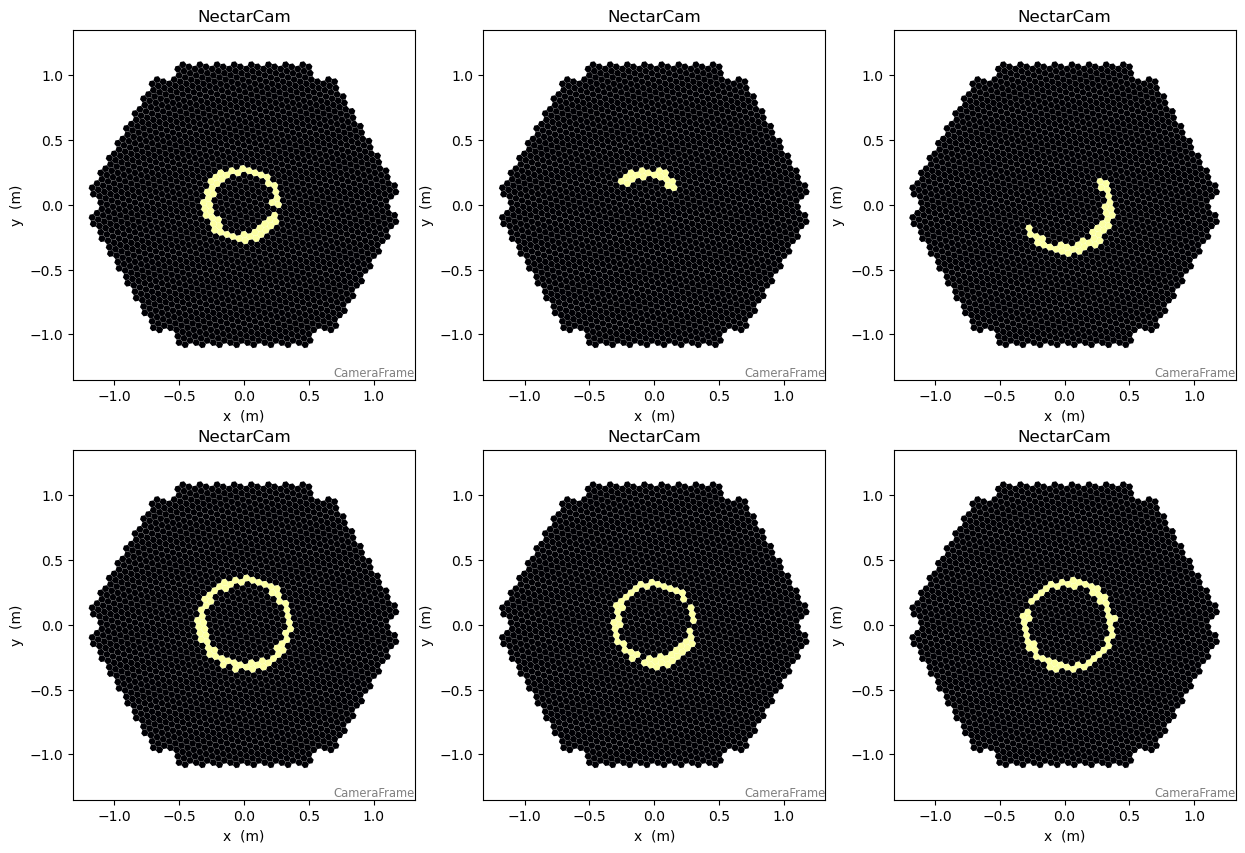

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][0],
    ax=ax[0][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][1],
    ax=ax[0][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][2],
    ax=ax[0][2])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][3],
    ax=ax[1][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][4],
    ax=ax[1][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][5],
    ax=ax[1][2])

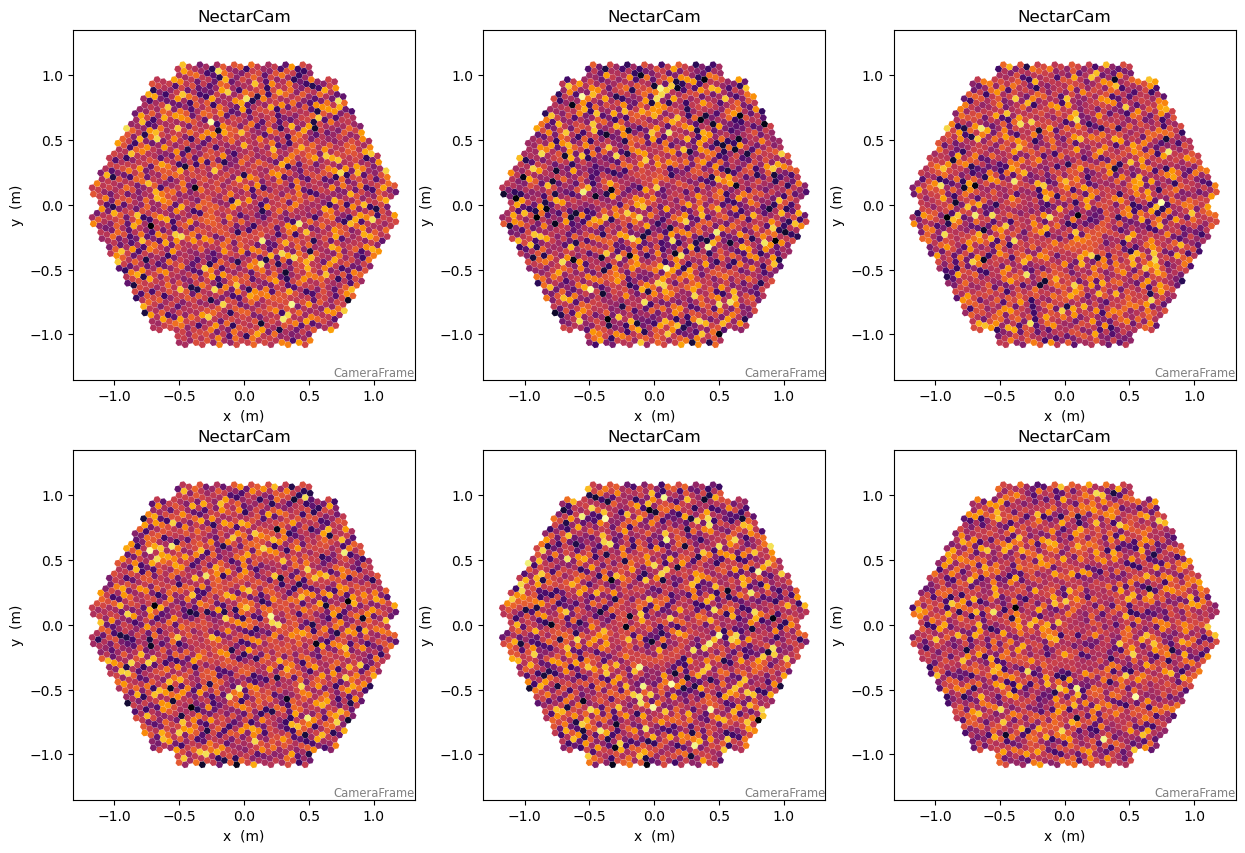

In [17]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][0],
    ax=ax[0][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][1],
    ax=ax[0][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][2],
    ax=ax[0][2])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][3],
    ax=ax[1][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][4],
    ax=ax[1][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][5],
    ax=ax[1][2])